# Graph link-prediction — `full_full` dataset (LORAX / Hladis M2OR)

> **Exploratory / rerun required.** Existing graph metrics use a provisional protocol (non-independent cold folds, train labels as MP edges, no validation-selected checkpoint) and are not final benchmark results. See `README.md`.

The most complete M2OR variant we have. Node features: **ESM2-650M mean** (proteins, same encoder as curated/full) + **ChemBERTa-77M** (molecules; the LORAX paper shows the molecule encoder is interchangeable, GIN covers only 64%). Reported head: unentangled **XGBoost** probe on `[raw ChemBERTa mol ‖ graph-enriched ESM prot]`.

**Two regimes** (rows of every plot):

- **transductive** — LORAX folds as-is: train/val = full noisy mix, test = EC50-only edges (~22% pos). All nodes known, edges held out (≈ stratified).
- **inductive_molecule** — cold start: whole molecules held out of the graph entirely, tested on their EC50 pairs (≈ group_molecule). Built in `orbind/lorax.py`; test stays EC50-only.

Grey bar = our plain `ESM‖ChemBERTa → XGBoost` baseline **on the same split, no graph** (`scripts/modeling/eval/eval_full_full_baseline.py`).

In [1]:
import sys, pathlib
ROOT = pathlib.Path.cwd()
while not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve
from orbind.dataset import metrics

FOLD = 1   # which LORAX random fold to display (1..5)
CKPT_DIR = ROOT / "results" / "full_full" / "checkpoints"
BASELINE_CSV = ROOT / "results" / "full_full" / "tables" / "baselines.csv"
REGIMES = ["transductive", "inductive_molecule"]
PLOT_METRICS = ["AUROC", "AUPRC", "MCC", "F1"]
print("ckpt_dir =", CKPT_DIR, "| fold =", FOLD)

ckpt_dir = c:\Users\User\Desktop\SberWork\orbind\results\full_full\checkpoints | fold = 1


In [2]:
# Load every full_full checkpoint for FOLD, keyed by (regime, arch, variant).
# variant = mp_mode [+ _q##] [+ _history]  — fully identifies a run.
def variant_of(ckpt):
    c = ckpt["config"]; v = c["mp_mode"]
    q = c.get("mol_quality_q", 0) or 0
    if q > 0: v += f"_q{int(q*100)}"
    if c.get("history", False):
        v += "_history" if c.get("history_depth", 2) >= 2 else "_hist1"
    if c.get("concat_raw_prot", False): v += "_rawp"
    return v

records, preds = [], {}
for path in sorted(CKPT_DIR.glob(f"*_fold{FOLD}.pt")):
    ckpt = torch.load(path, map_location="cpu", weights_only=False)
    regime, arch, var = ckpt["regime"], ckpt["arch"], variant_of(ckpt)
    _, test_y = ckpt["test_sup"]
    y, scores = test_y.numpy(), ckpt["test_scores"]
    records.append({"regime": regime, "arch": arch, "variant": var, **metrics(y, scores)})
    preds[(regime, arch, var)] = (y, scores)

df = (pd.DataFrame(records).set_index(["regime", "arch", "variant"]).sort_index().round(3)
      if records else pd.DataFrame())
print(f"{len(preds)} checkpoints loaded")
display(df)

46 checkpoints loaded


AUROC  AUPRC    MCC     F1  \
regime             arch variant                                             
inductive_molecule gat  all_edges              0.740  0.590  0.456  0.534   
                        pos_only               0.730  0.612  0.475  0.533   
                        signed                 0.746  0.607  0.496  0.562   
                        signed_history         0.772  0.636  0.483  0.552   
                        signed_q87             0.793  0.629  0.483  0.557   
                        signed_q95             0.804  0.648  0.504  0.595   
                        signed_q95_hist1       0.783  0.645  0.500  0.566   
                        signed_q95_hist1_rawp  0.787  0.647  0.498  0.561   
                        signed_q95_history     0.794  0.649  0.501  0.562   
                        signed_q99             0.756  0.545  0.274  0.455   
                        signed_rawp            0.763  0.648  0.514  0.587   
                   gnn  all_edges              0.767  0.613  0.468  0.551   
                        pos_only               0.737  0.611  0.495  0.557   
                        signed                 0.780  0.643  0.492  0.563   
                        signed_history         0.782  0.640  0.510  0.577   
                        signed_q87             0.817  0.627  0.477  0.552   
                        signed_q87_hist1       0.785  0.639  0.496  0.567   
                        signed_q87_history     0.796  0.639  0.508  0.577   
                        signed_q87_rawp        0.804  0.652  0.543  0.604   
                        signed_q95             0.783  0.641  0.486  0.561   
                        signed_q95_rawp        0.789  0.670  0.527  0.599   
                        signed_q99             0.792  0.635  0.496  0.574   
                        signed_rawp            0.769  0.627  0.521  0.580   
transductive       gat  all_edges              0.794  0.642  0.534  0.642   
                        pos_only               0.790  0.696  0.555  0.640   
                        signed                 0.799  0.640  0.573  0.660   
                        signed_history         0.801  0.657  0.598  0.677   
                        signed_q87             0.814  0.622  0.563  0.659   
                        signed_q95             0.832  0.639  0.540  0.648   
                        signed_q95_hist1       0.864  0.716  0.584  0.679   
                        signed_q95_hist1_rawp  0.876  0.731  0.613  0.702   
                        signed_q95_history     0.863  0.710  0.597  0.689   
                        signed_q99             0.764  0.560  0.315  0.492   
                        signed_rawp            0.830  0.686  0.634  0.711   
                   gnn  all_edges              0.838  0.699  0.564  0.666   
                        pos_only               0.784  0.681  0.592  0.670   
                        signed                 0.810  0.638  0.574  0.661   
                        signed_history         0.793  0.639  0.595  0.677   
                        signed_q87             0.821  0.660  0.572  0.661   
                        signed_q87_hist1       0.840  0.682  0.601  0.687   
                        signed_q87_history     0.834  0.669  0.598  0.682   
                        signed_q87_rawp        0.859  0.718  0.630  0.711   
                        signed_q95             0.853  0.694  0.593  0.685   
                        signed_q95_rawp        0.877  0.730  0.633  0.716   
                        signed_q99             0.852  0.709  0.569  0.670   
                        signed_rawp            0.821  0.666  0.616  0.694   

                                               precision  recall  
regime             arch variant                                   
inductive_molecule gat  all_edges                  0.695   0.434  
                        pos_only                   0.752   0.413  
                        signed                     0.747   0.450  
               

In [3]:
# No-graph XGBoost baseline on the SAME splits (both regimes) — the bar to beat
bl = pd.read_csv(BASELINE_CSV).set_index("regime")
BASE = {r: {m: float(bl.loc[r, m]) for m in PLOT_METRICS} for r in REGIMES}
for r in REGIMES:
    print(f"{r:20s} no-graph boost:", {k: round(v, 3) for k, v in BASE[r].items()})

transductive         no-graph boost: {'AUROC': 0.891, 'AUPRC': 0.755, 'MCC': 0.644, 'F1': 0.727}
inductive_molecule   no-graph boost: {'AUROC': 0.77, 'AUPRC': 0.621, 'MCC': 0.473, 'F1': 0.557}


In [4]:
# Reusable: rows = regimes, cols = metrics; bars = listed (arch, variant) + baseline
def plot_grid(specs, suptitle, savename, rot=0, fs=7):
    """specs: list of (display_name, color, arch, variant)."""
    names  = [s[0] for s in specs] + ["XGBoost\n(no graph)"]
    colors = [s[1] for s in specs] + ["#A0A0A0"]
    fig, axes = plt.subplots(len(REGIMES), len(PLOT_METRICS),
                              figsize=(1.0*len(names)*len(PLOT_METRICS), 3.8*len(REGIMES)))
    axes = np.array(axes).reshape(len(REGIMES), len(PLOT_METRICS))
    for ri, regime in enumerate(REGIMES):
        for mi, metric in enumerate(PLOT_METRICS):
            ax = axes[ri, mi]; base = BASE[regime][metric]
            vals = [df.loc[(regime, a, v), metric] if (regime, a, v) in df.index else float("nan")
                    for _, _, a, v in specs] + [base]
            bars = ax.bar(names, vals, color=colors)
            ax.axhline(base, color="#A0A0A0", ls="--", lw=1)
            ax.set_title(f"{regime} — {metric}", fontsize=9)
            ax.set_ylim(0, 1); ax.tick_params(axis="x", labelsize=fs, rotation=rot)
            for b, v in zip(bars, vals):
                if not np.isnan(v):
                    ax.text(b.get_x()+b.get_width()/2, v+0.02, f"{v:.3f}",
                            ha="center", va="bottom", fontsize=fs)
    fig.suptitle(suptitle, fontsize=12, y=1.01); plt.tight_layout()
    (ROOT/"notebooks/figures").mkdir(parents=True, exist_ok=True)
    plt.savefig(ROOT/f"notebooks/figures/{savename}.png", dpi=150, bbox_inches="tight")
    plt.show()

GNN_C = {"pos_only":"#4878CF","all_edges":"#6ACC65","signed":"#D65F5F"}
GAT_C = {"pos_only":"#3A5FA0","all_edges":"#4E9E4E","signed":"#9467BD"}

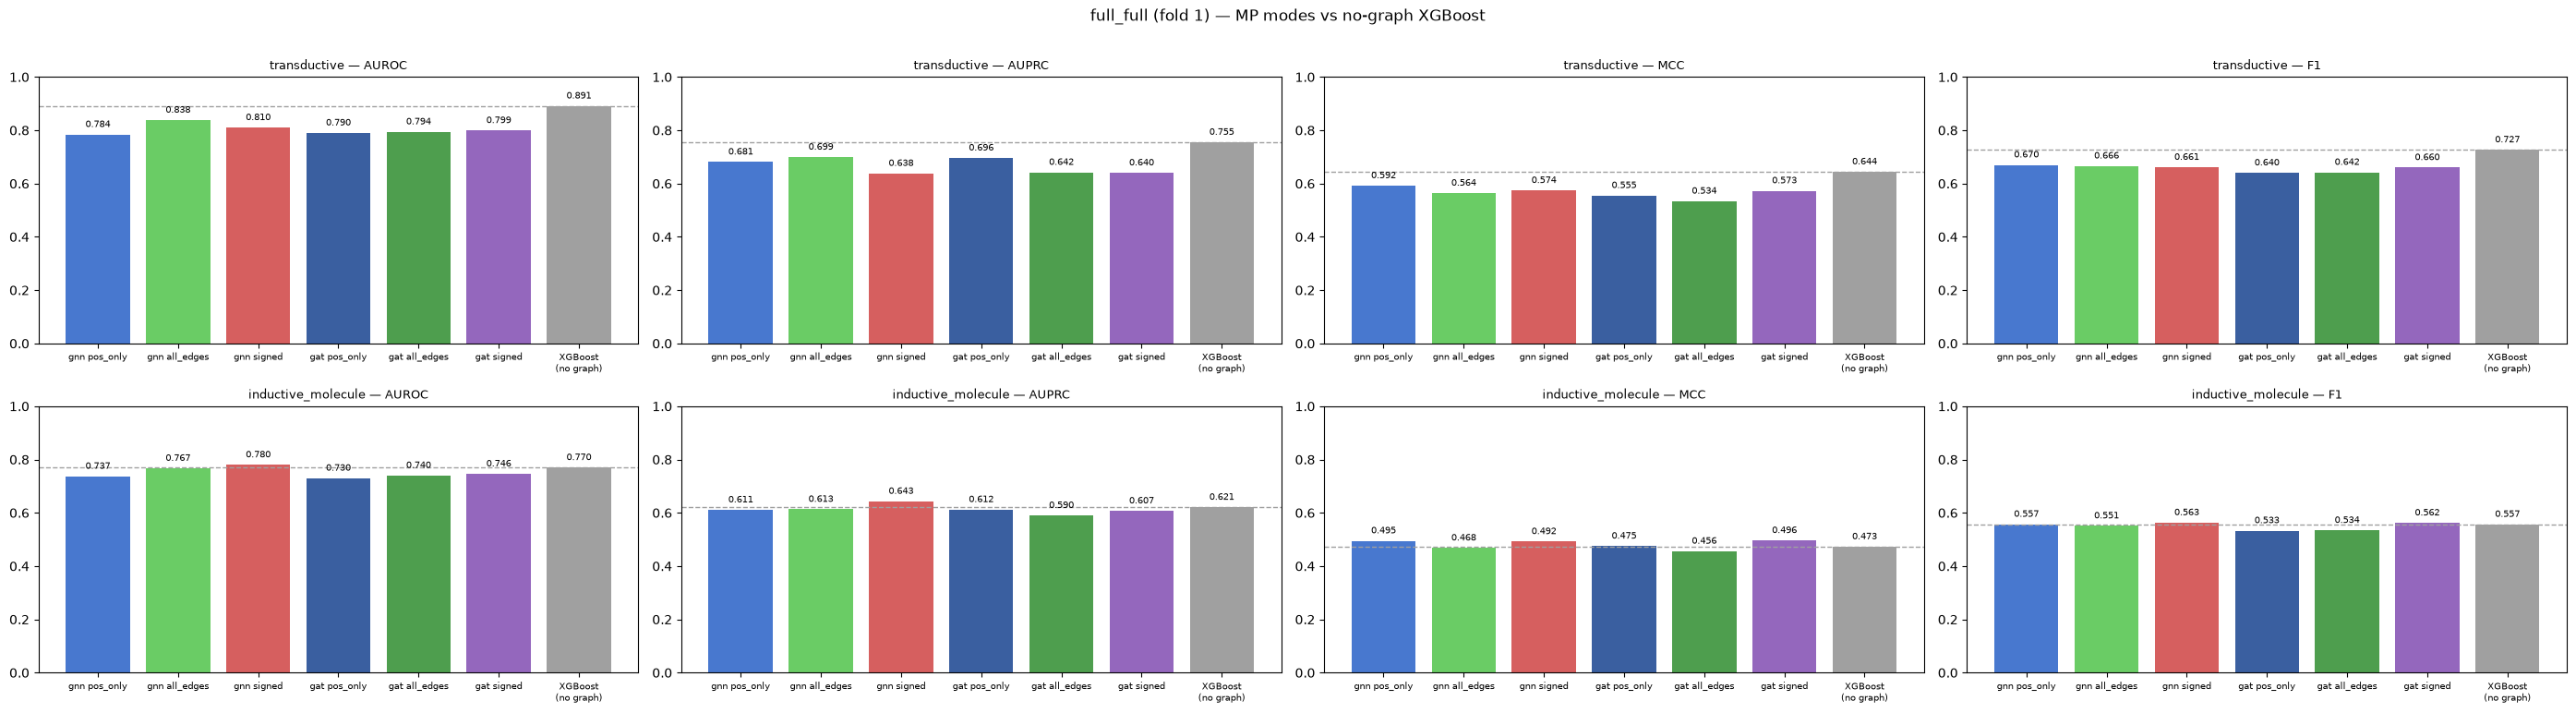

In [5]:
# Main comparison: 3 MP modes x {gnn, gat}, both regimes
specs = [("gnn pos_only", GNN_C["pos_only"], "gnn", "pos_only"),
         ("gnn all_edges", GNN_C["all_edges"], "gnn", "all_edges"),
         ("gnn signed",    GNN_C["signed"],    "gnn", "signed"),
         ("gat pos_only",  GAT_C["pos_only"],  "gat", "pos_only"),
         ("gat all_edges", GAT_C["all_edges"], "gat", "all_edges"),
         ("gat signed",    GAT_C["signed"],    "gat", "signed")]
plot_grid(specs, f"full_full (fold {FOLD}) — MP modes vs no-graph XGBoost",
          "graph_full_full_bars")

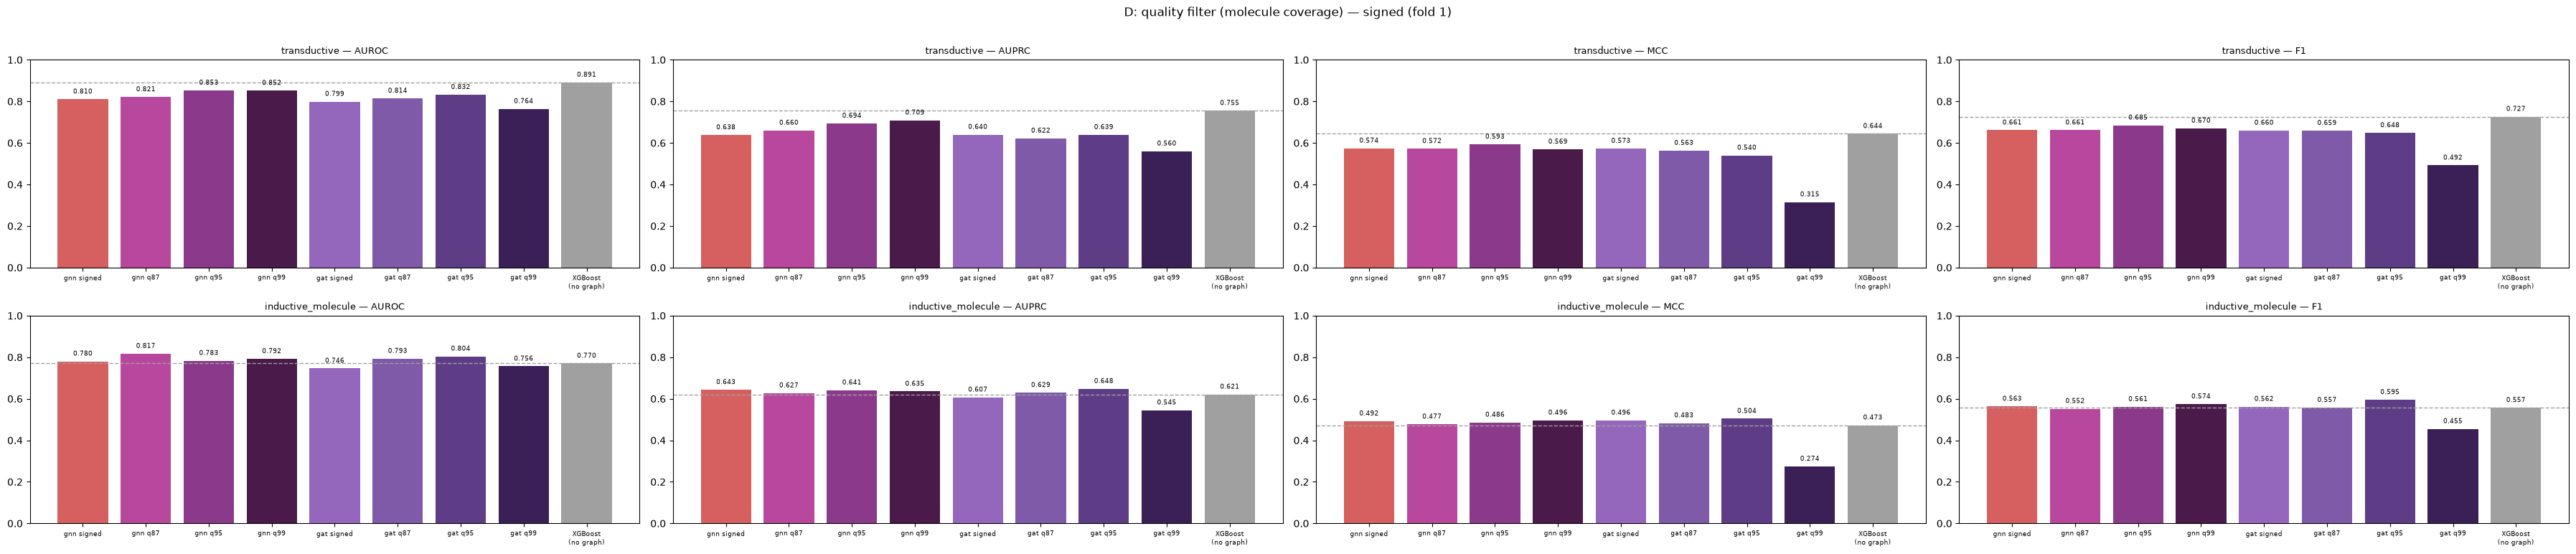

In [6]:
# D: molecule-coverage quality filter on the MP graph — signed, gnn & gat
specs = [("gnn signed",      "#D65F5F", "gnn", "signed"),
         ("gnn q87",         "#B8479E", "gnn", "signed_q87"),
         ("gnn q95",         "#8B3A8B", "gnn", "signed_q95"),
         ("gnn q99",         "#4A1A4A", "gnn", "signed_q99"),
         ("gat signed",      "#9467BD", "gat", "signed"),
         ("gat q87",         "#7E5AA8", "gat", "signed_q87"),
         ("gat q95",         "#5E3D86", "gat", "signed_q95"),
         ("gat q99",         "#3A2057", "gat", "signed_q99")]
plot_grid(specs, f"D: quality filter (molecule coverage) — signed (fold {FOLD})",
          "graph_full_full_quality", fs=6.5)

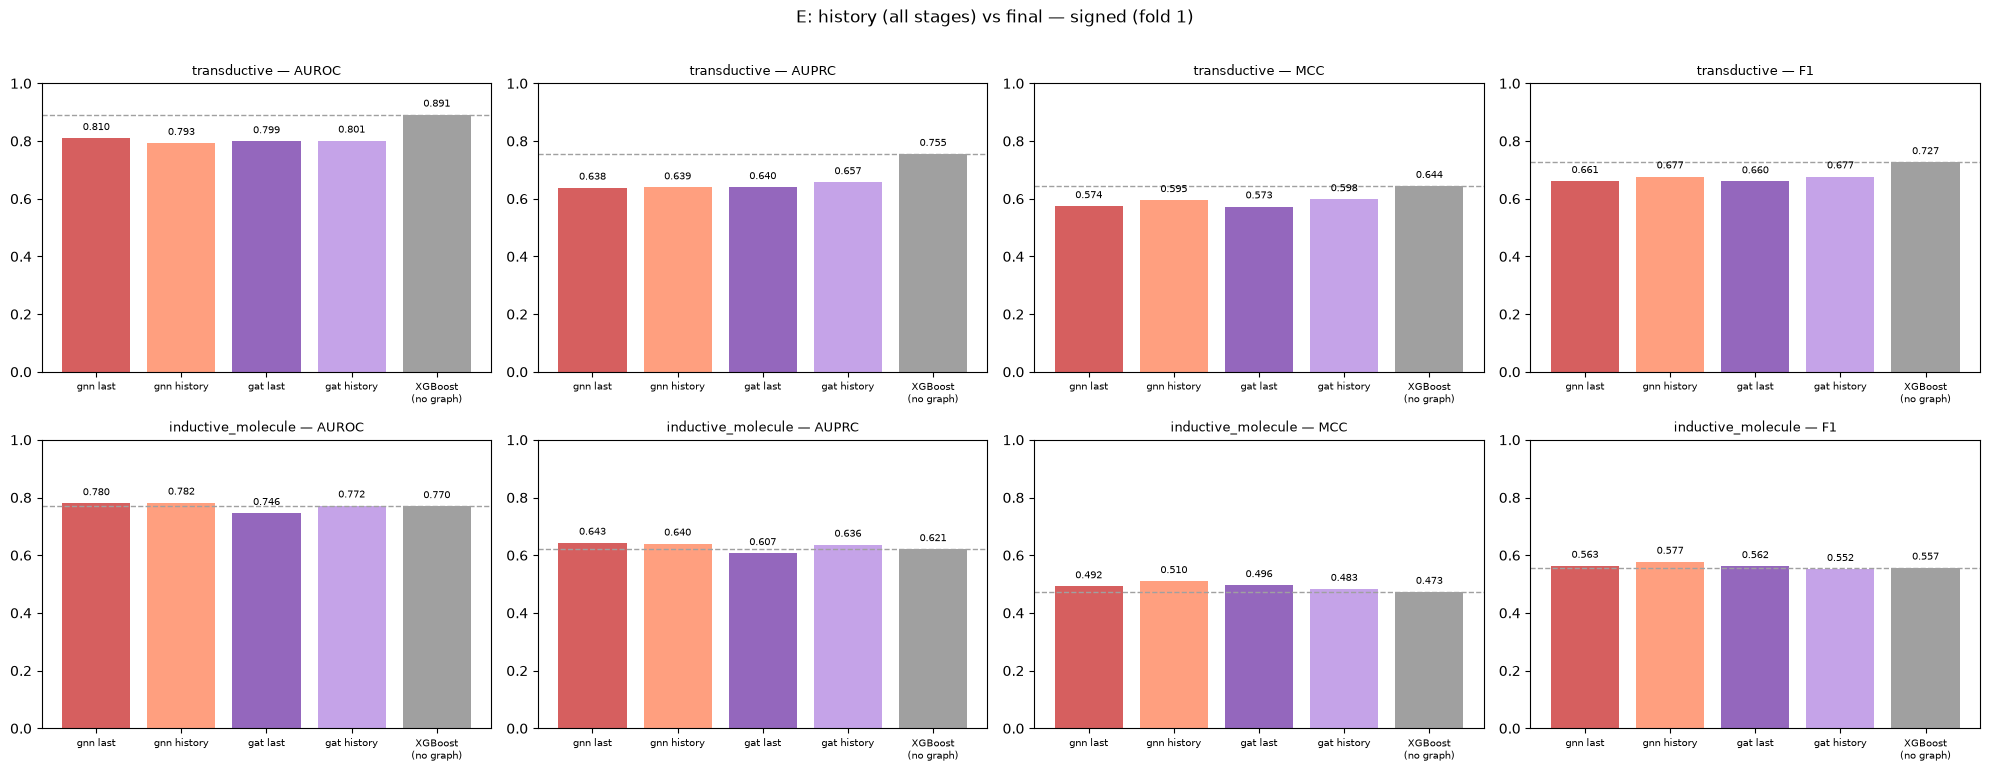

In [7]:
# E: concat all stages [x0||x1||x2] vs final z_prot — signed, gnn & gat
specs = [("gnn last",    "#D65F5F", "gnn", "signed"),
         ("gnn history", "#FF9F7F", "gnn", "signed_history"),
         ("gat last",    "#9467BD", "gat", "signed"),
         ("gat history", "#C5A3E8", "gat", "signed_history")]
plot_grid(specs, f"E: history (all stages) vs final — signed (fold {FOLD})",
          "graph_full_full_history")

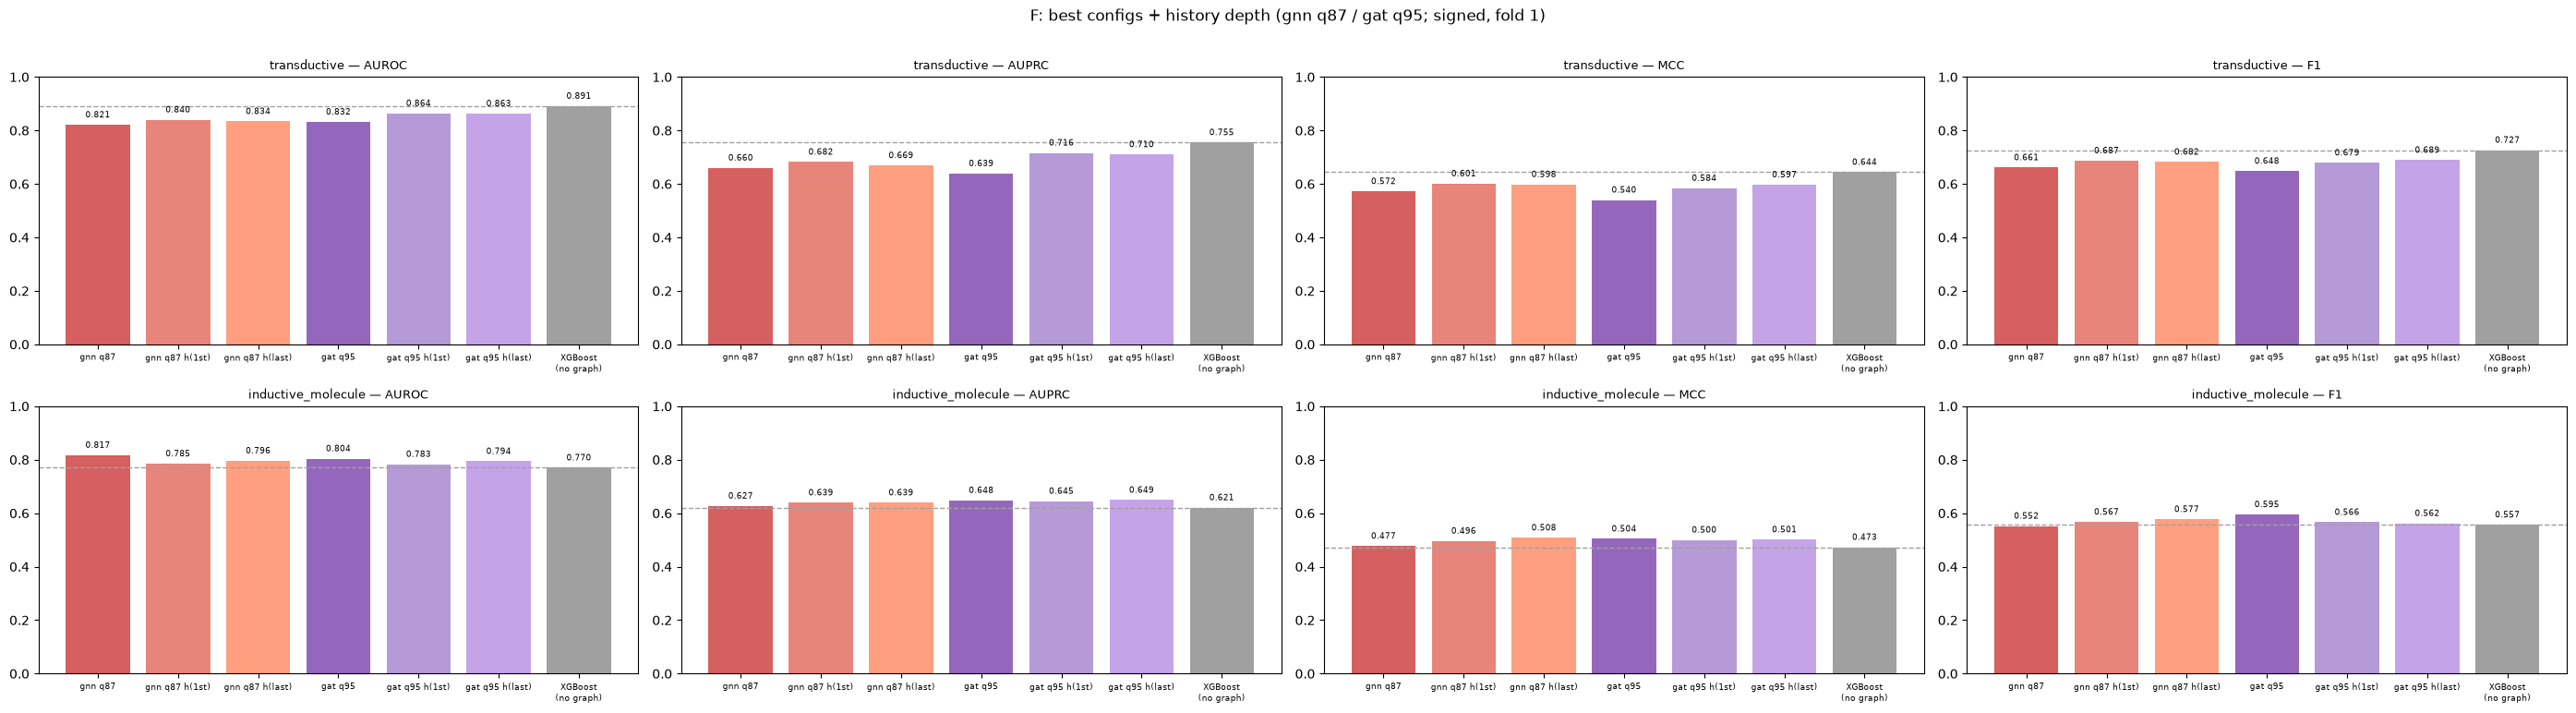

In [8]:
# F: best configs (gnn q87, gat q95) — final vs history(1st MP) vs history(last MP)
specs = [("gnn q87",            "#D65F5F", "gnn", "signed_q87"),
         ("gnn q87 h(1st)",     "#E8857A", "gnn", "signed_q87_hist1"),
         ("gnn q87 h(last)",    "#FF9F7F", "gnn", "signed_q87_history"),
         ("gat q95",            "#9467BD", "gat", "signed_q95"),
         ("gat q95 h(1st)",     "#B69AD8", "gat", "signed_q95_hist1"),
         ("gat q95 h(last)",    "#C5A3E8", "gat", "signed_q95_history")]
plot_grid(specs, f"F: best configs + history depth (gnn q87 / gat q95; signed, fold {FOLD})",
          "graph_full_full_best_history", fs=6.5)

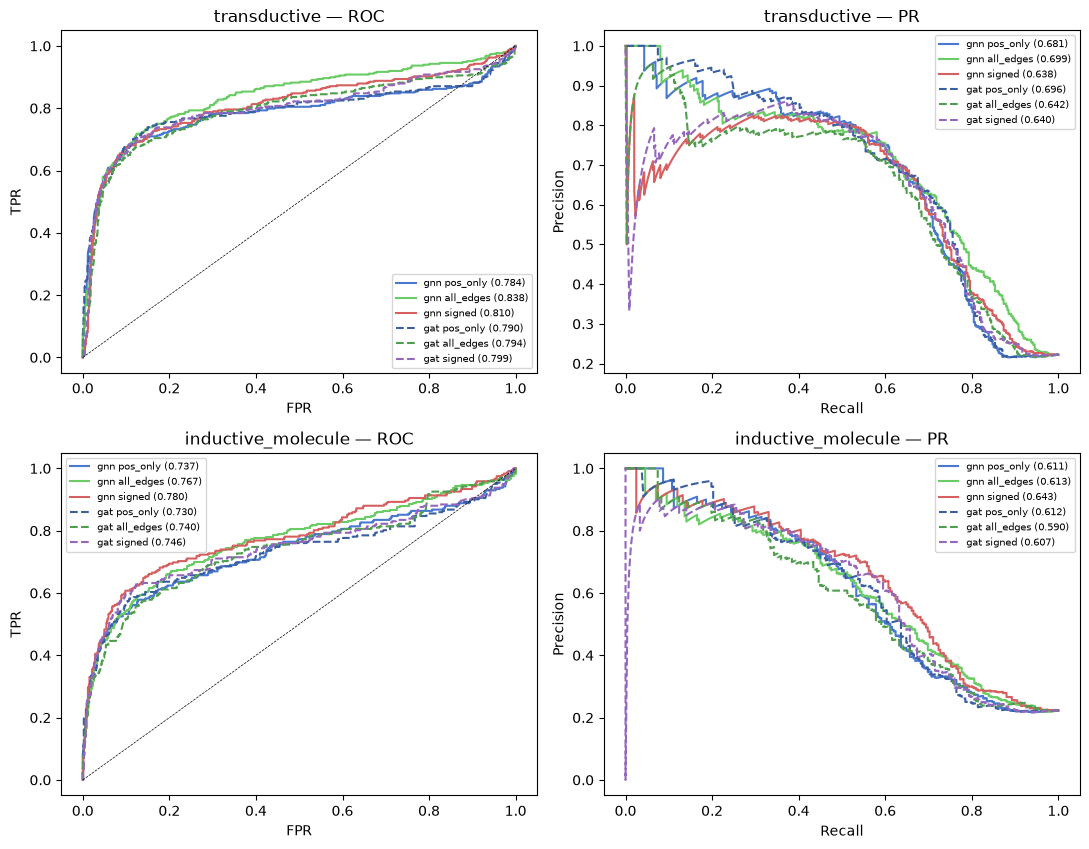

In [9]:
# ROC + PR curves per regime, base MP modes only
BASE_VARS = [("gnn","pos_only"),("gnn","all_edges"),("gnn","signed"),
             ("gat","pos_only"),("gat","all_edges"),("gat","signed")]
COL = {("gnn",m): GNN_C[m] for m in GNN_C}; COL.update({("gat",m): GAT_C[m] for m in GAT_C})
fig, axes = plt.subplots(len(REGIMES), 2, figsize=(11, 4.3*len(REGIMES)))
axes = np.array(axes).reshape(len(REGIMES), 2)
for ri, regime in enumerate(REGIMES):
    ax_roc, ax_pr = axes[ri]
    for a, v in BASE_VARS:
        if (regime, a, v) not in preds: continue
        y, sc = preds[(regime, a, v)]
        fpr, tpr, _ = roc_curve(y, sc); prec, rec, _ = precision_recall_curve(y, sc)
        ls = "-" if a == "gnn" else "--"
        ax_roc.plot(fpr, tpr, color=COL[(a,v)], ls=ls, label=f"{a} {v} ({df.loc[(regime,a,v),'AUROC']:.3f})")
        ax_pr.plot(rec, prec, color=COL[(a,v)], ls=ls, label=f"{a} {v} ({df.loc[(regime,a,v),'AUPRC']:.3f})")
    ax_roc.plot([0,1],[0,1],"k--",lw=0.5)
    ax_roc.set(title=f"{regime} — ROC", xlabel="FPR", ylabel="TPR"); ax_roc.legend(fontsize=7)
    ax_pr.set(title=f"{regime} — PR", xlabel="Recall", ylabel="Precision"); ax_pr.legend(fontsize=7)
plt.tight_layout()
plt.savefig(ROOT/"notebooks/figures/graph_full_full_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## Как читать

- **Серый пунктир** в каждой ячейке — наш бустинг без графа на тех же парах (`results/full_full/tables/baselines.csv`). Вопрос: добавляет ли граф что-то поверх `ESM‖ChemBERTa→XGBoost`.
- **Строка 1 (transductive)** — узлы общие, тест = EC50-рёбра; канон-планка (5 фолдов) в `results/lorax/lorax_compare.csv`.
- **Строка 2 (inductive_molecule)** — молекулы тест-набора cold; своя планка.
- **D** — фильтр MP-графа по покрытию молекулы (q = квантиль числа измерений). Это ортогонально качеству ассая (primary/secondary/ec50) — фильтруем по тому, насколько молекула хорошо промерена.
- **E** — `[x0‖x1‖x2]` (все стадии MP) vs финальный `z_prot` в фичах probe.

Сборка данных: `train_graph_full_full.py --mp_mode signed [--mol_quality_q q] [--history] --regime {transductive,inductive_molecule}`.